In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [34]:


#Read the CSV file with a comma delimeter
df = pd.read_csv('data/Hospital_Indonesia_datasets_Oryza Ayunda Putri - DataCleaning.csv', sep=',')

#cetak header data (5 baris data) dari file
df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,Median Total Tempat,total_tempat_tidur,median_total_layanan,total_layanan,median_otal_tenaga_kerja,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,218,36,36,328,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,45,15,15,45,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,310,77,77,487,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,11,24,24,182,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,Rumah Sakit Umum,C,BLUD,Pemkot,189,189,34,34,537,537


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        3155 non-null   int64 
 1   nama                      3155 non-null   object
 2   propinsi                  3155 non-null   object
 3   kab                       3155 non-null   object
 4   alamat                    3155 non-null   object
 5   jenis                     3155 non-null   object
 6   kelas                     3155 non-null   object
 7   status_blu                3155 non-null   object
 8   kepemilikan               3155 non-null   object
 9   Median Total Tempat       3155 non-null   int64 
 10  total_tempat_tidur        3155 non-null   int64 
 11  median_total_layanan      3155 non-null   int64 
 12  total_layanan             3155 non-null   int64 
 13  median_otal_tenaga_kerja  3155 non-null   int64 
 14  total_tenaga_kerja      

In [36]:
print(f"jenis: \n {df['jenis'].unique()}\n")
print(f"kelas: \n {df['kelas'].unique()}\n")
print(f"status_blu: \n {df['status_blu'].unique()}\n")
print(f"kepemilikan: \n {df['kepemilikan'].unique()}\n")

jenis: 
 ['Rumah Sakit Umum' 'Rumah Sakit Khusus Gigi dan Mulut'
 'Rumah Sakit Khusus Ibu dan Anak' 'Rumah Sakit Khusus Jiwa'
 'Rumah Sakit Khusus Bedah' 'Rumah Sakit Khusus Mata'
 'Rumah Sakit Khusus Paru' 'Rumah Sakit Khusus Ginjal'
 'Rumah Sakit Khusus Stroke' 'Rumah Sakit Khusus THT-KL'
 'Rumah Sakit Khusus Kanker' 'Rumah Sakit Khusus Infeksi'
 'Rumah Sakit Khusus Jantung' 'Rumah Sakit Khusus Otak'
 'Rumah Sakit Ketergantungan Obat' 'Rumah Sakit Khusus Orthopedi'
 'RS Kapal/Bergerak']

kelas: 
 ['C' 'D' 'B' 'D PRATAMA' 'A' 'Belum Ditetapkan' 'Rumah Sakit Umum'
 'Rumah Sakit Khusus Jiwa']

status_blu: 
 ['Non BLU/BLUD' 'BLUD' 'BLU' 'D' 'A' 'C' 'D PRATAMA']

kepemilikan: 
 ['SWASTA/LAINNYA' 'Pemkot' 'Kementerian Lain' 'Pemkab' 'Perusahaan'
 'Organisasi Sosial' 'POLRI' 'TNI AD' 'TNI AL' 'BUMN' 'Pemprop'
 'Perorangan' 'Organisasi Katholik' 'Organisasi Protestan' 'Kemkes'
 'TNI AU' 'Organisasi Islam' 'Organisasi Budha' 'BLUD' 'BLU'
 'Non BLU/BLUD' 'Organisasi Hindu']



Cleaning

In [37]:
df[df['kelas']=='D PRATAMA'][['nama','kelas','jenis']]

,nama,kelas,jenis
25,RS Umum Daerah Type D Pratama T. Cut Ali,D PRATAMA,Rumah Sakit Umum
32,RS Umum Daerah dr. Muchtar Hasbi,D PRATAMA,Rumah Sakit Umum
99,RS Pratama Kab. Nias Barat,D PRATAMA,Rumah Sakit Umum
244,RS Pratama Lologolu Soguna Ba Zato,D PRATAMA,Rumah Sakit Umum
312,RS Umum Daerah Kamang Baru,D PRATAMA,Rumah Sakit Umum
...,...,...,...
3117,RS Umum Daerah Pratama Dogiyai,D PRATAMA,Rumah Sakit Umum
3138,RS Umum Daerah Ilaga,D PRATAMA,Rumah Sakit Umum
3144,RS Bergerak Kab. Boven Digoel,D PRATAMA,Rumah Sakit Umum
3146,RS Umum Daerah Karubaga,D PRATAMA,Rumah Sakit Umum


In [38]:
df[df['kelas'] == 'Rumah Sakit Khusus Jiwa'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
1746,RS Khusus Jiwa Puri Nirmala,Rumah Sakit Khusus Jiwa,Rumah Sakit Umum


In [39]:
df.loc[df['nama'] == 'RS Umum Daerah Kepulauan Seribu','kelas'] = 'D'
df.loc[df['nama'] == 'RS Umum Pusat Dr. Soeradji Tirtonegoro','kelas'] = 'A'
df.loc[df['nama'] == 'RS Umum Daerah Kawera','kelas'] = 'D PRATAMA'
df.loc[df['nama'] == 'Rumah Sakit Khusus Jiwa','kelas'] = 'C'

In [40]:
kelas_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'D PRATAMA': 0,
    'Belum Ditetapkan': -1 
}
df['kelas'] = df['kelas'].map(kelas_mapping)

In [41]:
df = pd.get_dummies(df, columns=['jenis','kepemilikan'])

In [42]:
df.head()

,id,nama,propinsi,kab,alamat,kelas,status_blu,Median Total Tempat,total_tempat_tidur,median_total_layanan,...,kepemilikan_POLRI,kepemilikan_Pemkab,kepemilikan_Pemkot,kepemilikan_Pemprop,kepemilikan_Perorangan,kepemilikan_Perusahaan,kepemilikan_SWASTA/LAINNYA,kepemilikan_TNI AD,kepemilikan_TNI AL,kepemilikan_TNI AU
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,2.0,Non BLU/BLUD,218,218,36,...,False,False,False,False,False,False,True,False,False,False
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,1.0,Non BLU/BLUD,45,45,15,...,False,False,False,False,False,False,True,False,False,False
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,3.0,BLUD,310,310,77,...,False,False,True,False,False,False,False,False,False,False
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,3.0,BLU,11,11,24,...,False,False,False,False,False,False,False,False,False,False
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,2.0,BLUD,189,189,34,...,False,False,True,False,False,False,False,False,False,False


feature selection

In [43]:
df_cluster = df.drop(columns=['id', 'nama', 'propinsi', 'kab', 'alamat', 'status_blu'])

normalisasi

In [44]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_cluster)

modeling

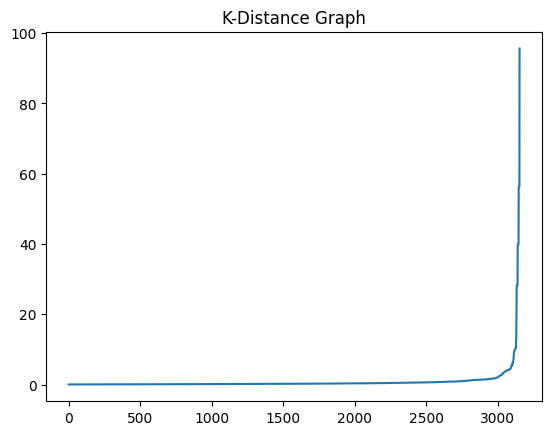

In [45]:
neighbors = NearestNeighbors(n_neighbors=5)
# Handle NaN values by removing rows with NaN
mask = ~np.isnan(x_scaled).any(axis=1)
x_scaled_clean = x_scaled[mask]
distances, _ = neighbors.fit(4 x_scaled_clean).kneighbors(x_scaled_clean)
distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title('K-Distance Graph')
plt.show()

In [47]:
best_score = -1
for eps in np.arange(2, 5.1, 0.1):
    for min_samples in range(120, 140):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(x_scaled_clean)
        if len(set(labels)) > 2:  # Ensure there are at least 2 clusters
            score = silhouette_score(x_scaled_clean, labels)
            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

EVALUASI

In [48]:
print("best EPS:", best_eps)
print("best min_samples:", best_min_samples)
print("best silhouette score:", round(best_score, 4))

best EPS: 2.7000000000000006
best min_samples: 120
best silhouette score: 0.2445


In [49]:
unique, counts = np.unique(best_labels, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"Noise: {count} titik")
    else:
        print(f"Cluster {label}: {count} titik")

    

Noise: 1060 titik
Cluster 0: 664 titik
Cluster 1: 642 titik
Cluster 2: 393 titik
Cluster 3: 152 titik
Cluster 4: 243 titik


In [53]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)
clusters = dbscan.fit_predict(x_scaled_clean)
df.loc[mask, 'cluster'] = clusters

In [54]:
cluster_summary = df.groupby('cluster')[[
    'total_tempat_tidur',
    'total_layanan',
    'total_tenaga_kerja'
]].mean()

print(cluster_summary)

         total_tempat_tidur  total_layanan  total_tenaga_kerja
cluster                                                       
-1.0             166.935849      42.342453          322.404717
 0.0             114.783133      44.364458          194.756024
 1.0             145.566978      39.493769          330.998442
 2.0             118.394402      43.595420          195.073791
 3.0              38.875000      19.559211           63.078947
 4.0             113.942387      40.465021          233.399177


In [56]:
#PCA 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(x_scaled_clean)

#BUAT DATAFRAME SEDERHANA
df_plot = pd.DataFrame({
   'PC1': X_pca[:, 0],
   'PC2': X_pca[:, 1],
   'PC3': X_pca[:, 2],
   'cluster': clusters
})

#3D INTERACTIVE PLOT
fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    title='DBSCAN + PCA 3D (Interactive)'
)

fig.show()